# Thi is a notebook to test the project utilities

## Testing first reconstruction function in `recon/`

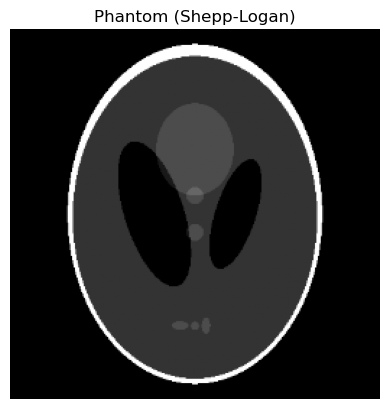

In [1]:
import sys
sys.path.append('../recon/')

from recon_utils import *
from skimage.data import shepp_logan_phantom
from skimage.transform import resize

phantom = shepp_logan_phantom()
phantom = resize(phantom, (256, 256), mode='reflect', anti_aliasing=True)

plt.imshow(phantom, cmap='gray')
plt.title("Phantom (Shepp-Logan)")
plt.axis('off')
plt.show()

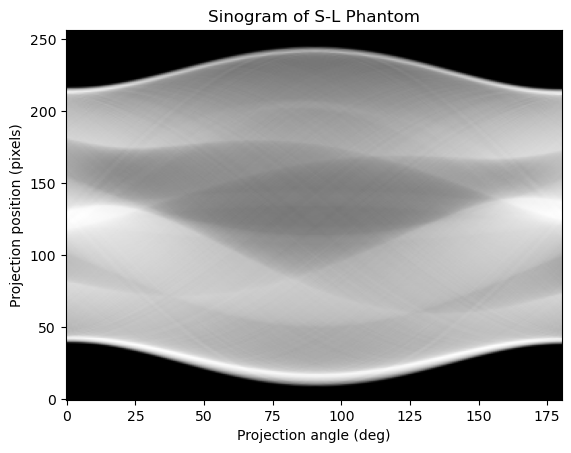

In [2]:
max_angle = 180
sinogram, angles = sinogramFromPhantom(phantom, max_angle=max_angle)

dx, dy = 0.5*max_angle/max(phantom.shape), 0.5
plt.imshow(sinogram, cmap=plt.cm.Greys_r, extent=(-dx, max_angle+dx, -dy, sinogram.shape[0]+dy) ,aspect='auto')
plt.title("Sinogram of S-L Phantom")
plt.xlabel("Projection angle (deg)")
plt.ylabel("Projection position (pixels)")
plt.show()

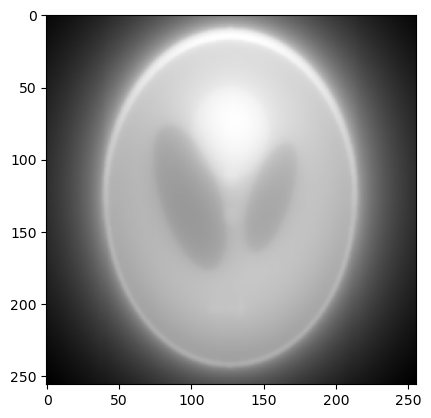

In [4]:
backproj = backprojection(sinogram, angles)
plt.imshow(backproj, cmap='gray')